In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import gc
import gzip
import numpy as np
import mne
import json
from sklearn.preprocessing import LabelEncoder
from torch.nn import Module, Linear , LayerNorm, BatchNorm1d, Dropout
import torch.nn.functional as F
import torch
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
import networkx as nx
from collections import Counter
from snntorch import spikegen
import warnings
import random
import pyarrow
from snntorch import spikegen
import torch
import random
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
import snntorch
import imblearn
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from typing import Literal, Optional, Tuple
import joblib
import shap

mne.set_log_level("ERROR")


In [ ]:
def set_global_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(False, warn_only=True)

In [3]:
# -----------------------------
# SNN that consumes [T, B, F]
# -----------------------------
class SNNModel(nn.Module):
    """Spiking Neural Network that accepts spike trains shaped [T, B, F]."""
    def __init__(self, input_size: int, hidden_size: int, output_size: int, beta: float = 0.5, num_steps: int = 25):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.lif1 = snn.Leaky(beta=beta, threshold=THRESHOLD, spike_grad=surrogate.fast_sigmoid())

        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.lif2 = snn.Leaky(beta=beta, threshold=THRESHOLD, spike_grad=surrogate.fast_sigmoid())

        self.fc3 = nn.Linear(hidden_size, output_size)
        self.lif3 = snn.Leaky(beta=beta, threshold=THRESHOLD, spike_grad=surrogate.fast_sigmoid())

        self.num_steps = int(num_steps)

    def forward(self, x_TBF: torch.Tensor):
        assert x_TBF.dim() == 3, f"Expected [T,B,F], got {tuple(x_TBF.shape)}"
        T, B, _ = x_TBF.shape
        device = x_TBF.device

        mem1 = torch.zeros(B, self.fc1.out_features, device=device)
        mem2 = torch.zeros(B, self.fc2.out_features, device=device)
        mem3 = torch.zeros(B, self.fc3.out_features, device=device)

        spk3_rec, mem3_rec = [], []
        for t in range(T):
            x = x_TBF[t]                 # [B,F]
            cur1 = self.fc1(x)           # [B,H]
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)        # [B,H]
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.fc3(spk2)        # [B,C]
            spk3, mem3 = self.lif3(cur3, mem3)

            spk3_rec.append(spk3)
            mem3_rec.append(mem3)

        return torch.stack(spk3_rec, 0), torch.stack(mem3_rec, 0)  # [T,B,C]

In [ ]:
def encode_to_spikes_eval(
    x: torch.Tensor,          # [B,F] after StandardScaler
    num_steps: int,
    method: str = "rate",
    gain: float = 1
) -> torch.Tensor:

    if method == "rate":
        x_norm = torch.sigmoid(x)
        return spikegen.rate(x_norm, num_steps=num_steps, gain=gain)

    elif method == "latency":
        x_norm = torch.clamp(x, -2, 2)
        x_norm = (x_norm + 2) / 4          # [0,1]
        
        x_enc = torch.clamp(x_norm * gain, 0.0, 1.0)
        
        return spikegen.latency(
            x_enc,
            num_steps=num_steps,
            threshold=0.05,
            tau=1.0,
            first_spike_time=0,
            normalize=False,
            linear=True,
            clip=True
        )

    else:
        raise ValueError(method)

@torch.no_grad()
def infer_logits_batched(
    model: torch.nn.Module,
    X_float: torch.Tensor,
    batch_size: int = 128,
    encoding_method: str = "rate",
    num_steps: int | None = None,
    gain: float = 0.3,
    device: str | torch.device = "cpu",
) -> torch.Tensor:
    model.eval().to(device)
    X_float = X_float.to(device)
    N = X_float.shape[0]
    steps = int(num_steps or getattr(model, "num_steps", 25))

    outs = []
    for i in range(0, N, batch_size):
        xb = X_float[i:i+batch_size]                  
        spikes = encode_to_spikes_eval(
            xb,
            num_steps=steps,
            method=encoding_method,
            gain=gain,
        ).to(device)

        spk_rec, mem_rec = model(spikes)

        if encoding_method == "rate":
            out = spk_rec.sum(dim=0)
        elif encoding_method == "latency":
            out = mem_rec.max(dim=0).values
        else:
            raise ValueError(f"Unknown encoding method: {encoding_method}")

        outs.append(out.detach().cpu())

    return torch.cat(outs, dim=0)

In [ ]:
import os
import json
import pandas as pd

ALL_FEATURE_SETS = ["katz", "bands_rel", "bands_abs", "f1_slope_calc_by_me", "f1_slope_calc_by_fooof", "plv", "mean_std"]


def _cache_paths(cache_prefix: str):
    return {
        "X":   f"{cache_prefix}X.parquet",
        "y":   f"{cache_prefix}y.parquet",
        "meta": f"{cache_prefix}meta.parquet",
        "chs":  f"{cache_prefix}channels.json",
        "cfg":  f"{cache_prefix}config.json",
    }


def load_extracted_features(
    features, 
    cache_root: str = "./cache/"
):
    if isinstance(features, str):
            feature_list = [features]
    else:
        feature_list = list(features)

    if not feature_list:
        raise ValueError("No features requested.")

    X_all = []
    y_ser_ref = None
    meta_ref = None
    channels_ref = None
    cfg_merged: dict = {}

    for feat_name in feature_list:
        sub_list = [feat_name]

        for fn in sub_list:
            cache_prefix = os.path.join(cache_root, fn, "")
            paths = _cache_paths(cache_prefix)

            missing = [k for k, p in paths.items() if k in ("X", "y", "meta") and not os.path.exists(p)]
            if missing:
                raise FileNotFoundError(
                    f"Missing cached files for feature '{fn}' in '{cache_prefix}': {missing}"
                )

            print(f"[cache] Loading features '{fn}' from '{cache_prefix}_*.parquet'")

            X_df  = pd.read_parquet(paths["X"])
            y_ser = pd.read_parquet(paths["y"])["label"]
            meta  = pd.read_parquet(paths["meta"])

            if os.path.exists(paths["chs"]):
                with open(paths["chs"], "r") as f:
                    chs = json.load(f)
            else:
                chs = None

            cfg_local = {}
            if os.path.exists(paths["cfg"]):
                with open(paths["cfg"], "r") as f:
                    cfg_local = json.load(f)

            if y_ser_ref is None:
                y_ser_ref = y_ser
                meta_ref  = meta
                channels_ref = chs
            else:
                if len(y_ser) != len(y_ser_ref):
                    raise ValueError(
                        f"Feature set '{fn}' has {len(y_ser)} samples, "
                        f"but previous set has {len(y_ser_ref)}."
                    )
            X_df_prefixed = X_df.add_prefix(f"{fn}__")

            X_all.append(X_df_prefixed)

            cfg_merged.update(cfg_local)

    if not X_all:
        raise RuntimeError("No feature matrices were loaded; check 'features' and cache_root.")

    X_concat = pd.concat(X_all, axis=1)

    print(f"[cache] Final concatenated X shape: {X_concat.shape}")
    return X_concat, y_ser_ref, meta_ref, channels_ref, cfg_merged

def _cache_paths(cache_prefix: str):
    return {
        "X": f"{cache_prefix}X.parquet",
        "y": f"{cache_prefix}y.parquet",
        "meta": f"{cache_prefix}meta.parquet",
        "chs": f"{cache_prefix}channels.json",
        "cfg": f"{cache_prefix}config.json",
    }

In [ ]:
df_participants = pd.read_csv("participants.tsv", sep='\t')

FEATURES = "all_features" #["plv", "bands_rel", "bands_abs", "mean_std"]

X_df, y_ser, meta, used_channels, _cfg = load_extracted_features(FEATURES)

print("\nPreview X_df:")
display(X_df.head())
print("\nPreview y_ser (A->0, C->1):")
display(y_ser.head())
print("\nMeta (subject windows):")
display(meta.head())
print(X_df.columns)

[cache] Loading features 'all_features' from './cache/all_features/_*.parquet'
[cache] Final concatenated X shape: (53150, 399)

Preview X_df:


,all_features__mean_C3,all_features__mean_C4,all_features__mean_Cz,all_features__mean_F3,all_features__mean_F4,all_features__mean_F7,all_features__mean_F8,all_features__mean_Fp1,all_features__mean_Fp2,all_features__mean_Fz,...,all_features__plv__Pz__T3,all_features__plv__Pz__T4,all_features__plv__Pz__T5,all_features__plv__Pz__T6,all_features__plv__T3__T4,all_features__plv__T3__T5,all_features__plv__T3__T6,all_features__plv__T4__T5,all_features__plv__T4__T6,all_features__plv__T5__T6
0,-0.000006,-0.000004,-0.000007,-0.000008,-0.000006,-0.000004,-0.000003,-0.000001,-0.000003,-0.000006,...,0.979723,0.974370,0.985267,0.982265,0.976173,0.981932,0.966881,0.970489,0.957331,0.973272
1,-0.000011,-0.000011,-0.000011,-0.000011,-0.000012,-0.000010,-0.000010,-0.000011,-0.000012,-0.000012,...,0.985520,0.981469,0.988134,0.983172,0.984029,0.986635,0.973079,0.976346,0.962411,0.976064
2,0.000024,0.000023,0.000024,0.000024,0.000023,0.000023,0.000020,0.000024,0.000023,0.000022,...,0.991029,0.991655,0.990359,0.993360,0.988706,0.993074,0.987625,0.980551,0.989684,0.987641
3,0.000003,0.000003,0.000004,0.000002,0.000003,0.000002,0.000001,0.000003,0.000003,0.000002,...,0.990961,0.987635,0.995158,0.994665,0.991723,0.994320,0.992208,0.988449,0.992556,0.995723
4,-0.000018,-0.000018,-0.000017,-0.000017,-0.000016,-0.000018,-0.000015,-0.000021,-0.000018,-0.000017,...,0.930378,0.893427,0.969564,0.965880,0.971928,0.950046,0.958654,0.912931,0.932175,0.970390



Preview y_ser (A->0, C->1):


0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64


Meta (subject windows):


,participant_id,window_idx
0,sub-001,0
1,sub-001,1
2,sub-001,2
3,sub-001,3
4,sub-001,4


Index(['all_features__mean_C3', 'all_features__mean_C4',
       'all_features__mean_Cz', 'all_features__mean_F3',
       'all_features__mean_F4', 'all_features__mean_F7',
       'all_features__mean_F8', 'all_features__mean_Fp1',
       'all_features__mean_Fp2', 'all_features__mean_Fz',
       ...
       'all_features__plv__Pz__T3', 'all_features__plv__Pz__T4',
       'all_features__plv__Pz__T5', 'all_features__plv__Pz__T6',
       'all_features__plv__T3__T4', 'all_features__plv__T3__T5',
       'all_features__plv__T3__T6', 'all_features__plv__T4__T5',
       'all_features__plv__T4__T6', 'all_features__plv__T5__T6'],
      dtype='str', length=399)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# === Subject-wise 80/20 train-test split ===
assert "participant_id" in meta.columns, "meta must contain 'participant_id'."

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_df, y_ser, groups=meta['participant_id']))

X_train = X_df.iloc[train_idx].reset_index(drop=True)
y_train = y_ser.iloc[train_idx].reset_index(drop=True)
meta_train = meta.iloc[train_idx].reset_index(drop=True)

X_test  = X_df.iloc[test_idx].reset_index(drop=True)
y_test  = y_ser.iloc[test_idx].reset_index(drop=True)
meta_test = meta.iloc[test_idx].reset_index(drop=True)

print(f"Train windows: {len(X_train)} | Test windows: {len(X_test)}")
print("Train label counts:", y_train.value_counts().to_dict())
print("Test  label counts:", y_test.value_counts().to_dict())
print("Train subjects:", meta_train['participant_id'].nunique(),
      "| Test subjects:", meta_test['participant_id'].nunique())

Train windows: 41713 | Test windows: 11437
Train label counts: {0: 22776, 1: 18937}
Test  label counts: {0: 6305, 1: 5132}
Train subjects: 52 | Test subjects: 13


In [ ]:
class SNNTrainer:
    def __init__(self, X_df, y_ser, device=None, random_state=42):
        self.device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
        self.random_state = random_state
        
        y = y_ser
        if y.dtype.kind not in "iu":
            y = y.astype(str).str.upper().map({"A": 0, "C": 1})
        self.y_np = y.to_numpy()

        self.X_np = X_df.to_numpy(dtype=np.float32)
        assert np.isfinite(self.X_np).all()

        print(f"Using device: {self.device}")

    def _prep_data(self, use_smote=True):
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(self.X_np).astype(np.float32)
        self.scaler_ = scaler

        if use_smote:
            smote = SMOTE(random_state=self.random_state)
            X_res, y_res = smote.fit_resample(X_scaled, self.y_np)
        else:
            X_res, y_res = X_scaled, self.y_np

        return (
            torch.tensor(X_res, dtype=torch.float32),
            torch.tensor(y_res, dtype=torch.long),
            scaler
        )

    def _encode_to_spikes(self, x, num_steps, method="rate", gain=0.3):
        return encode_to_spikes_eval(x, num_steps, method, gain)

    def train(self, num_epochs=50, batch_size=32, hidden_size=64,
              num_steps=25, beta=0.7, lr=1e-3,
              encoding_method="rate", use_smote=True, gain=0.3,
              save_prefix="./eeg_snn"):

        X_t, y_t, scaler = self._prep_data(use_smote)
        dataset = torch.utils.data.TensorDataset(X_t, y_t)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

        self.cfg_ = {"num_steps": num_steps, "encoding_method": encoding_method}
        model = SNNModel(X_t.shape[1], hidden_size, 2, beta=beta, num_steps=num_steps).to(self.device)
        self.model_ = model

        opt = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.CrossEntropyLoss()

        print(f"Starting SNN training (encoding={encoding_method})...")

        for epoch in range(1, num_epochs + 1):
            model.train()
            epoch_loss = 0

            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                
                spikes = self._encode_to_spikes(xb, num_steps, encoding_method, gain).to(self.device)
                spk_rec, mem_rec = model(spikes)

                if encoding_method == "latency":
                    out = mem_rec[-1]
                else:
                    out = spk_rec.sum(0)

                loss = loss_fn(out, yb)
                opt.zero_grad()
                loss.backward()
                opt.step()

                epoch_loss += loss.item()

            if epoch % 10 == 0 or epoch == 1 or epoch == num_epochs:
                acc = self.evaluate(model, X_t, y_t, encoding_method, num_steps, gain)
                avg_loss = epoch_loss / len(loader)
                print(f"Epoch {epoch:03d} | avg_loss={avg_loss:.4f} | acc={acc:.4f}")

        torch.save(model.state_dict(), f"{save_prefix}_model.pt")
        joblib.dump(scaler, f"{save_prefix}_scaler.pkl")
        print(f"Saved model -> {save_prefix}_model.pt ; scaler -> {save_prefix}_scaler.pkl")

        return model

    @torch.no_grad()
    def evaluate(self, model, X_all, y_all, encoding_method, num_steps, gain):
        model.eval()
        spikes = self._encode_to_spikes(X_all.to(self.device), num_steps, encoding_method, gain)
        spk_rec, mem_rec = model(spikes)

        if encoding_method == "latency":
            out = mem_rec[-1]
        else:
            out = spk_rec.sum(0)
            
        pred = out.argmax(1)
        return (pred == y_all.to(self.device)).float().mean().item()

In [ ]:
trainer = SNNTrainer(X_df, y_ser)

set_global_seed(42)
# "rate" or "latency"
CODING_METHOD = "latency"
BETA = 0.9
LEARNING_RATE = 5e-4
NUM_STEPS = 60
HIDDEN_SIZE = 128
NUM_EPOCHS = 50
THRESHOLD = 0.5
GAIN = 0.8

model = trainer.train(
    num_epochs=NUM_EPOCHS,
    batch_size=64,
    hidden_size=HIDDEN_SIZE,
    num_steps=NUM_STEPS,
    beta=BETA,
    lr=LEARNING_RATE,
    encoding_method=CODING_METHOD,
    use_smote=False,
    gain=GAIN,
    save_prefix="./eeg_snn"
)

scaler = trainer.scaler_
model  = trainer.model_
cfg    = trainer.cfg_

Using device: cpu
Starting SNN training (encoding=latency)...
Epoch 001 | avg_loss=0.6546 | acc=0.7411
Epoch 010 | avg_loss=0.3500 | acc=0.8473
Epoch 020 | avg_loss=0.3090 | acc=0.8716
Epoch 030 | avg_loss=0.2722 | acc=0.8897
Epoch 040 | avg_loss=0.2469 | acc=0.9069
Epoch 050 | avg_loss=0.2382 | acc=0.9071
Saved model -> ./eeg_snn_model.pt ; scaler -> ./eeg_snn_scaler.pkl



=== Model config ===
CODING: latency LEARNING RATE: 0.0005 BETA: 0.9
NUM_STEPS: 60 HIDDEN_SIZE: 128 NUM_EPOCHS: 50
FEATURES: all_features THRESHOLD: 0.5

=== Window-level ===
Accuracy: 0.8925
Balanced Accuracy: 0.8876
Macro F1: 0.8904

Confusion matrix (rows=true A,C; cols=pred A,C):
 [[5894  411]
 [ 819 4313]]

Classification report:
               precision    recall  f1-score   support

           A     0.8780    0.9348    0.9055      6305
           C     0.9130    0.8404    0.8752      5132

    accuracy                         0.8925     11437
   macro avg     0.8955    0.8876    0.8904     11437
weighted avg     0.8937    0.8925    0.8919     11437


=== Subject-level ===
Subject Accuracy: 1.0000
Subject Balanced Accuracy: 1.0000
Subject Macro F1: 1.0000

Subject-level confusion matrix (rows=true A,C; cols=pred A,C):
 [[7 0]
 [0 6]]


,Pred A,Pred C
True A,7,0
True C,0,6


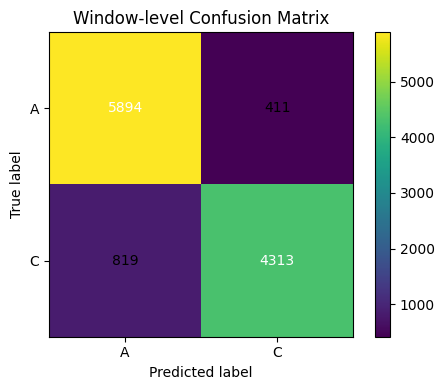

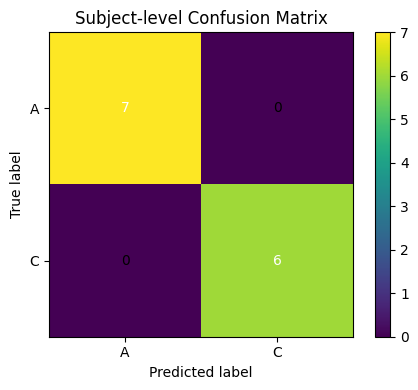

In [ ]:
# === Validation (window- and subject-level) ===
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix
)

X_test_scaled = scaler.transform(X_test.values).astype("float32")
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

logits = infer_logits_batched(
    model,
    X_test_t,
    batch_size=128,
    encoding_method=cfg["encoding_method"],
    num_steps=cfg["num_steps"],
    gain=GAIN,
    device=trainer.device,
)
y_pred = logits.argmax(dim=1).cpu().numpy()
y_true = np.asarray(y_test)

label_names = ["A", "C"]  # 0 -> A, 1 -> C

# ---------- Model config ----------
print("\n=== Model config ===")
print(f'CODING: {CODING_METHOD} LEARNING RATE: {LEARNING_RATE} BETA: {BETA}')
print(f'NUM_STEPS: {NUM_STEPS} HIDDEN_SIZE: {HIDDEN_SIZE} NUM_EPOCHS: {NUM_EPOCHS}')
print(f'FEATURES: {FEATURES} THRESHOLD: {THRESHOLD}')
# ---------- Window-level ----------
print("\n=== Window-level ===")
acc_win = accuracy_score(y_true, y_pred)
bal_win = balanced_accuracy_score(y_true, y_pred)
f1m_win  = f1_score(y_true, y_pred, average="macro")
print(f"Accuracy: {acc_win:.4f}")
print(f"Balanced Accuracy: {bal_win:.4f}")
print(f"Macro F1: {f1m_win:.4f}")

cm_win = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("\nConfusion matrix (rows=true A,C; cols=pred A,C):\n", cm_win)

print("\nClassification report:\n",
      classification_report(y_true, y_pred, target_names=label_names, digits=4))

# ---------- Subject-level majority vote with logit tie-break ----------
df_pred = meta_test.copy()
df_pred["y_true"] = y_true
df_pred["y_pred"] = y_pred
logits_np = logits.detach().cpu().numpy()
for c in range(logits_np.shape[1]):
    df_pred[f"logit_{c}"] = logits_np[:, c]

def _mode_strict(s: pd.Series) -> int:
    vc = s.value_counts()
    winners = sorted(vc[vc == vc.max()].index.tolist())
    return int(winners[0])

def _vote_with_logit_tiebreak(g: pd.DataFrame) -> int:
    vc = g["y_pred"].value_counts()
    winners = vc[vc == vc.max()].index.tolist()
    if len(winners) == 1:
        return int(winners[0])
    sums = {cls: g[f"logit_{cls}"].sum() for cls in winners}
    best = max(sums.values())
    winners2 = [cls for cls, s in sums.items() if np.isclose(s, best)]
    return int(min(winners2))

subj = df_pred.groupby("participant_id").apply(
    lambda g: pd.Series({
        "y_true": _mode_strict(g["y_true"]),
        "y_pred": _vote_with_logit_tiebreak(g),
        "n_windows": len(g)
    })
).reset_index()

print("\n=== Subject-level ===")
acc_subj = accuracy_score(subj["y_true"], subj["y_pred"])
bal_subj = balanced_accuracy_score(subj["y_true"], subj["y_pred"])
f1m_subj = f1_score(subj["y_true"], subj["y_pred"], average="macro")
print(f"Subject Accuracy: {acc_subj:.4f}")
print(f"Subject Balanced Accuracy: {bal_subj:.4f}")
print(f"Subject Macro F1: {f1m_subj:.4f}")

cm_subj = confusion_matrix(subj["y_true"], subj["y_pred"], labels=[0, 1])
print("\nSubject-level confusion matrix (rows=true A,C; cols=pred A,C):\n", cm_subj)

cm_df = pd.DataFrame(cm_subj, index=["True A", "True C"], columns=["Pred A", "Pred C"])
display(cm_df)

def plot_cm(cm, title="Confusion Matrix", ticklabels=("A","C")):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(ticklabels))
    plt.xticks(ticks, ticklabels)
    plt.yticks(ticks, ticklabels)
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

plot_cm(cm_win,  title="Window-level Confusion Matrix",  ticklabels=label_names)
plot_cm(cm_subj, title="Subject-level Confusion Matrix", ticklabels=label_names)

In [11]:
import numpy as np
import pandas as pd


X_test_scaled = scaler.transform(X_test.values).astype(np.float32)

y_test_np = np.asarray(y_test).astype(np.int64)

pd.DataFrame(X_test_scaled).to_csv(
    "X_test_scaled.csv",
    index=False,
    float_format="%.8f"
)

pd.DataFrame({"label": y_test_np}).to_csv(
    "y_test.csv",
    index=False
)

pd.DataFrame({
    "participant_id": meta_test["participant_id"].values
}).to_csv(
    "participant_id_test.csv",
    index=False
)

print("Saved:")
print(" - X_test_scaled.csv", X_test_scaled.shape)
print(" - y_test.csv", y_test_np.shape)
print(" - participant_id_test.csv")

Saved:
 - X_test_scaled.csv (11437, 399)
 - y_test.csv (11437,)
 - participant_id_test.csv


In [12]:
import pandas as pd
import numpy as np

state_dict = model.state_dict()

w1 = state_dict["fc1.weight"].cpu().numpy().astype(np.float32)
b1 = state_dict["fc1.bias"].cpu().numpy().astype(np.float32)

w2 = state_dict["fc2.weight"].cpu().numpy().astype(np.float32)
b2 = state_dict["fc2.bias"].cpu().numpy().astype(np.float32)

pd.DataFrame(w1).to_csv("w1.csv", index=False, float_format="%.10f")
pd.DataFrame(b1).to_csv("b1.csv", index=False, float_format="%.10f")

pd.DataFrame(w2).to_csv("w2.csv", index=False, float_format="%.10f")
pd.DataFrame(b2).to_csv("b2.csv", index=False, float_format="%.10f")

print("Saved weights as CSV:")
print("w1:", w1.shape)
print("b1:", b1.shape)
print("w2:", w2.shape)
print("b2:", b2.shape)

Saved weights as CSV:
w1: (128, 399)
b1: (128,)
w2: (128, 128)
b2: (128,)


In [13]:
import json

config = {
    "num_steps": NUM_STEPS,
    "gain": GAIN,
    "beta": BETA,
    "hidden_size": HIDDEN_SIZE,
    "encoding_method": CODING_METHOD
}

with open("snn_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("Saved snn_config.json")

Saved snn_config.json
